<a href="https://colab.research.google.com/github/astriadf/H1D024004-PraktikumKB-Pertemuan7/blob/main/pert7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* **Nama: Astria Dina Fitri**
* **NIM: H1D024004**
* **Shift Lama: G**
* **Shift Baru: D**

* **Praktikum Kecerdasan Buatan Pertemuan 7 - Jaringan Syaraf Tiruan 2**

In [2]:
# Mengekstrak file ZIP
!unzip iris.zip

Archive:  iris.zip
  inflating: Index                   
  inflating: bezdekIris.data         
  inflating: iris.data               
  inflating: iris.names              


In [27]:
# Import library untuk deep learning dan neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential        # Model sekuensial (layer berurutan)
from tensorflow.keras.layers import Dense, Input      # Layer dense (fully connected)

# Import library untuk manipulasi data
import pandas as pd
import numpy as np
import seaborn as sns                                 # Untuk visualisasi data
import matplotlib.pyplot as plt                       # Untuk membuat visualisasi/grafik

# Import library untuk preprocessing dan evaluasi
from sklearn.preprocessing import LabelEncoder        # Mengubah label string ke numerik
from sklearn.model_selection import train_test_split  # Membagi data train-test
from sklearn.metrics import confusion_matrix          # Untuk evaluasi hasil klasifikasi model

In [28]:
# ========== LOAD DATASET ==========
# Muat dataset iris dari file CSV/data
dataset = pd.read_csv('iris.data', header=None)

# Menyusun data X (fitur) dan y (label)
X = dataset.iloc[:, :-1].values  # 4 kolom pertama sebagai fitur
y = dataset.iloc[:, -1].values   # Kolom terakhir sebagai label

In [29]:
# ========== PREPROCESSING DATA ==========
# Mengonversi label dari string menjadi numerik
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y) # Mengubah label menjadi angka (0, 1, 2)

In [30]:
# Memisahkan dataset menjadi data latih dan data validasi dengan rasio 80:20
# train_test_split membagi data secara acak
# test_size=0.2 berarti 20% untuk testing, 80% untuk training
# random_state=42 untuk reproducibility (hasil split selalu sama)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# ========== MEMBANGUN MODEL NEURAL NETWORK ==========
model = Sequential([
    # Input layer: menerima 4 fitur (sepal length, sepal width, petal length, petal width)
    Input(shape=X_train.shape[1:]),

    # Hidden layer 1: 1000 neuron dengan aktivasi ReLU
    # Dense = fully connected layer (setiap neuron terhubung ke semua neuron layer sebelumnya)
    # ReLU (Rectified Linear Unit): f(x) = max(0, x) - menghilangkan nilai negatif
    Dense(1000, activation='relu'),

    # Hidden layer 2: 500 neuron dengan aktivasi ReLU
    # Jumlah neuron berkurang bertahap untuk ekstraksi fitur
    Dense(500, activation='relu'),

    # Hidden layer 3: 300 neuron dengan aktivasi ReLU
    Dense(300, activation='relu'),

    # Output layer: 3 neuron (untuk 3 kelas: setosa, versicolor, virginica)
    # Softmax: mengubah output menjadi probabilitas (jumlah = 1)
    Dense(3, activation='softmax')
])

In [32]:
# Menampilkan ringkasan arsitektur model
# Menunjukkan jumlah parameter (bobot dan bias) yang perlu dilatih
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1000)           │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,703 (2.51 MB)

 Trainable params: 656,703 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# ========== COMPILE MODEL ==========
# Konfigurasi model sebelum training
model.compile(
    # Optimizer: algoritma untuk update bobot
    # Adam: adaptive learning rate, kombinasi momentum dan RMSprop (populer dan efektif)
    optimizer='adam',

    # Loss function: fungsi untuk mengukur error
    # sparse_categorical_crossentropy: untuk klasifikasi multi-class dengan label integer
    # Mengukur perbedaan antara probabilitas prediksi dengan label sebenarnya
    loss='sparse_categorical_crossentropy',

    # Metrics: metrik evaluasi yang ditampilkan saat training
    # Accuracy: persentase prediksi yang benar
    metrics=['accuracy']
)

In [34]:
# ========== TRAINING MODEL ==========
# Melatih model dengan data training
# History menyimpan riwayat loss dan accuracy setiap epoch untuk visualisasi
history = model.fit(
    X_train, y_train,                   # Data training (fitur dan label)
    epochs=50,                          # Jumlah iterasi training (50 kali melewati seluruh data)
    batch_size=32,                      # Jumlah sampel per update bobot (32 sampel sekaligus)
    validation_data=(X_test, y_test)    # Data validasi untuk mengukur performa saat training
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.4583 - loss: 1.0607 - val_accuracy: 0.6333 - val_loss: 0.8989
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.7333 - loss: 0.6954 - val_accuracy: 0.7000 - val_loss: 0.5196
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7333 - loss: 0.4946 - val_accuracy: 0.8333 - val_loss: 0.4034
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9333 - loss: 0.3611 - val_accuracy: 0.8667 - val_loss: 0.3085
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9333 - loss: 0.2834 - val_accuracy: 0.8667 - val_loss: 0.2685
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9333 - loss: 0.2222 - val_accuracy: 0.9000 - val_loss: 0.2071
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9667 - loss: 0.1724 - val_accuracy: 0.8333 - val_loss: 0.2500
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9417 - loss: 0.1757 - val_accuracy: 0.8333 - val_loss: 0.392

In [35]:
# ========== EVALUASI MODEL ==========
# Mengevaluasi performa model pada data test
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")
# Loss: seberapa besar error model (semakin kecil semakin baik)
# Accuracy: persentase prediksi benar (semakin tinggi semakin baik)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.2014
Loss: 0.2013673633337021, Accuracy: 0.8999999761581421


<Axes: >

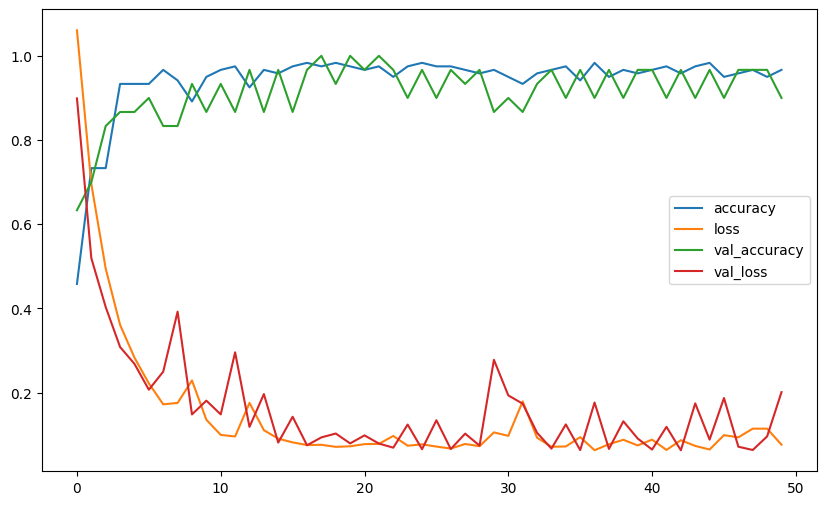

In [36]:
# Visualisasi history training (loss dan accuracy)
# Grafik ini menunjukkan apakah model overfit atau underfit
# Jika training loss turun tapi validation loss naik = overfit
# Jika kedua loss tinggi = underfit
pd.DataFrame(history.history).plot(figsize=(10,6))

In [37]:
# ========== PREDIKSI DATA TEST ==========
# Melakukan prediksi pada data test
predictions = model.predict(X_test)
# predictions berisi probabilitas untuk setiap kelas

# Mengambil indeks dari nilai probabilitas tertinggi untuk setiap prediksi
# argmax mencari index dengan nilai maksimum
# axis=1 berarti mencari per baris (per sampel)
predicted_classes = predictions.argmax(axis=1)
print("Prediksi:", predicted_classes)
print("Label Asli:", y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediksi: [1 0 2 2 1 0 1 2 2 1 2 0 0 0 0 1 2 1 2 2 0 2 0 2 2 2 2 2 0 0]
Label Asli: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


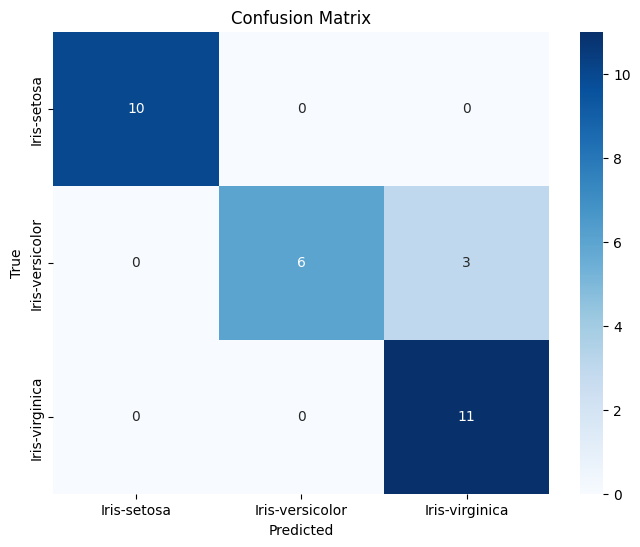

In [38]:
# ========== CONFUSION MATRIX ==========
# Buat confusion matrix
# Confusion matrix menunjukkan berapa banyak prediksi benar/salah untuk setiap kelas
# Baris = label asli, Kolom = prediksi
cm = confusion_matrix(y_test, predicted_classes)

# Visualisasikan confusion matrix
plt.figure(figsize=(8, 6))
# annot=True: tampilkan angka di setiap cell
# fmt='d': format integer
# cmap='Blues': skema warna biru
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [39]:
# ========== PREDIKSI DATA BARU ==========
# Fungsi untuk memprediksi data input baru
def predict_new_data():
    # Input fitur bunga iris dari user
    sepal_length = float(input("Masukkan sepal length: "))
    sepal_width = float(input("Masukkan sepal width: "))
    petal_length = float(input("Masukkan petal length: "))
    petal_width = float(input("Masukkan petal width: "))

    # Membuat data array baru dengan format yang sama seperti data training
    # Harus dalam bentuk 2D array: [[fitur1, fitur2, fitur3, fitur4]]
    new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Melakukan prediksi menggunakan model yang sudah dilatih
    prediction = model.predict(new_data)

    # Mengambil kelas dengan probabilitas tertinggi
    predicted_class = prediction.argmax(axis=1)

    # Mengonversi hasil prediksi numerik menjadi label asli (nama spesies)
    # inverse_transform: angka -> string
    predicted_label = label_encoder.inverse_transform(predicted_class)
    print(f"Prediksi kelas: {predicted_label[0]}")

# Panggil fungsi prediksi
predict_new_data()

Masukkan sepal length: 5.1
Masukkan sepal width: 3.5
Masukkan petal length: 1.4
Masukkan petal width: 0.2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediksi kelas: Iris-setosa
